# 💾 1. Extração Dinâmica e Unificação (ETL)

🔄 A iniciar a extração dos dados brutos do repositório...

✔️ loja_1.csv carregado com sucesso.
✔️ loja_2.csv carregado com sucesso.
✔️ loja_3.csv carregado com sucesso.
✔️ loja_4.csv carregado com sucesso.

✅ Unificação concluída! 9435 registos.

A aplicar transformações e limpeza de dados...


/tmp/ipykernel_236/1904073300.py:69: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_clean[col_data] = pd.to_datetime(df_clean[col_data], errors='coerce')


,produto,categoria_do_produto,preço,frete,data_da_compra,vendedor,local_da_compra,avaliação_da_compra,tipo_de_pagamento,quantidade_de_parcelas,lat,lon,filial,faturamento_total
0,Assistente virtual,eletronicos,219.08,9.249790,2021-01-16,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1,1752.64
1,Mesa de jantar,moveis,256.35,11.234305,2022-05-18,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1,1025.40
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,2021-03-15,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1,279.51
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,2022-05-03,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1,1009.99
4,Cadeira de escritório,moveis,446.99,26.964689,2020-11-07,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1,446.99



A gerar visualizações...


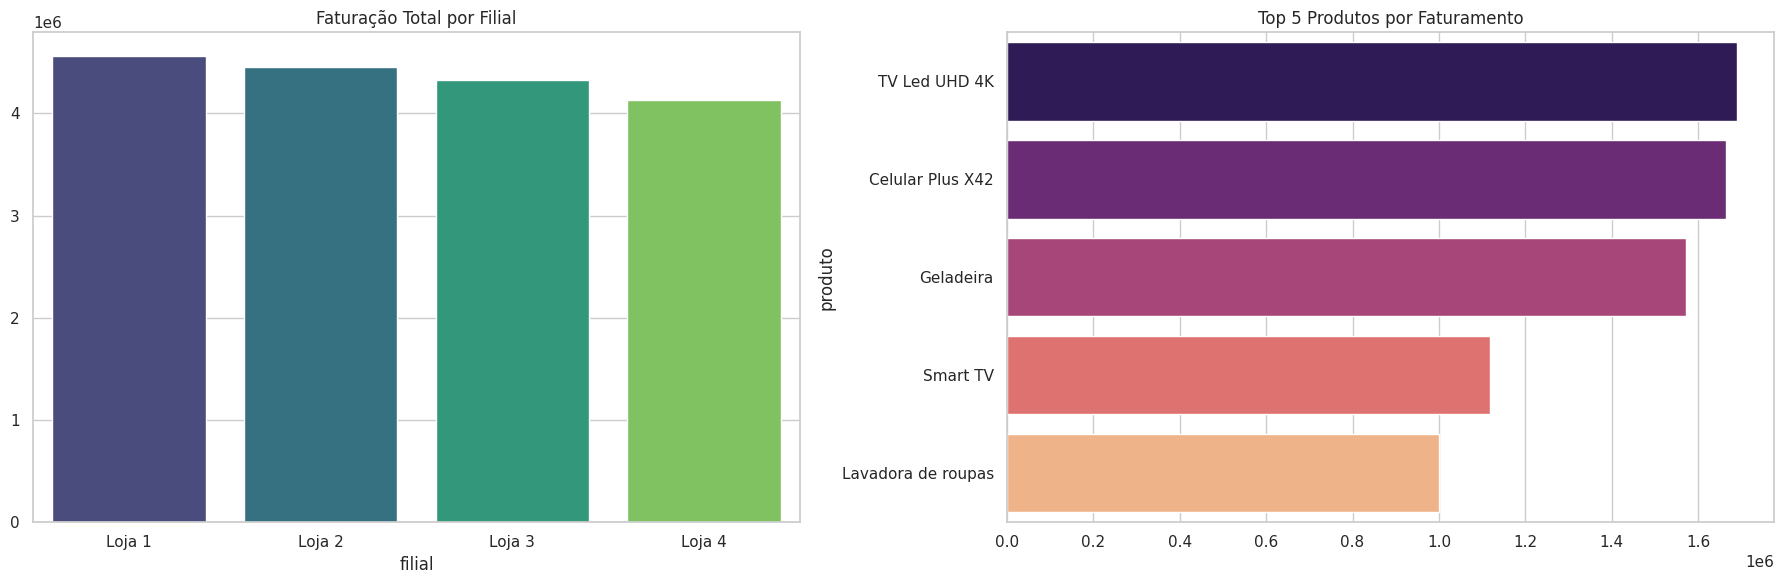

In [7]:
# ==============================================================================
# 1. IMPORTAÇÕES E CONFIGURAÇÃO INICIAL
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Configuração visual profissional para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==============================================================================
# 2. EXTRAÇÃO DE DADOS (ETL - Leitura via GitHub Raw)
# ==============================================================================
url_base_raw = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/main/base-de-dados-challenge-1/"
nomes_ficheiros = ['loja_1', 'loja_2', 'loja_3', 'loja_4', 'loja_5']
extensoes = ['.json', '.csv']

dfs_filiais = []
print("🔄 A iniciar a extração dos dados brutos do repositório...\n")

for nome in nomes_ficheiros:
    for ext in extensoes:
        url_ficheiro = f"{url_base_raw}{nome}{ext}"
        try:
            resposta = requests.head(url_ficheiro)
            if resposta.status_code == 200:
                if ext == '.json':
                    df_temp = pd.read_json(url_ficheiro)
                else:
                    df_temp = pd.read_csv(url_ficheiro)

                df_temp['filial'] = nome.replace('_', ' ').title()
                dfs_filiais.append(df_temp)
                print(f"✔️ {nome}{ext} carregado com sucesso.")
                break
        except Exception: continue

if not dfs_filiais:
    raise ValueError("❌ Não foi possível carregar nenhum ficheiro.")

df_bruto = pd.concat(dfs_filiais, ignore_index=True)
print(f"\n✅ Unificação concluída! {df_bruto.shape[0]} registos.\n")

# ==============================================================================
# 3. LIMPEZA E ENGENHARIA DE FEATURES (Data Cleaning)
# ==============================================================================
print("A aplicar transformações e limpeza de dados...")
df_clean = df_bruto.copy()

# 3.1. Padronização dos nomes das colunas
df_clean.columns = [str(col).strip().lower().replace(' ', '_') for col in df_clean.columns]

# Mapeamento robusto das colunas
col_preco = next((c for c in df_clean.columns if c in ['preço', 'preco', 'price', 'valor']), None)
col_qtd = next((c for c in df_clean.columns if any(x in c for x in ['quantidade', 'quant', 'qty', 'itens'])), None)
col_data = next((c for c in df_clean.columns if 'data' in c or 'date' in c), None)
col_produto = next((c for c in df_clean.columns if 'produto' in c or 'item' in c), None)

# 3.2. Limpeza monetária
if col_preco and df_clean[col_preco].dtype == 'O':
    df_clean[col_preco] = df_clean[col_preco].replace({r'[\$\R]': '', ' ': '', r'\.': '', ',': '.'}, regex=True)
    df_clean[col_preco] = pd.to_numeric(df_clean[col_preco], errors='coerce')

# 3.3. Conversão de Datas
if col_data:
    df_clean[col_data] = pd.to_datetime(df_clean[col_data], errors='coerce')

# 3.4. Geração de KPIs Financeiros
if col_preco and col_qtd:
    df_clean[col_qtd] = pd.to_numeric(df_clean[col_qtd], errors='coerce')
    df_clean['faturamento_total'] = df_clean[col_qtd] * df_clean[col_preco]
else:
    print("⚠️ Atenção: Colunas essenciais não identificadas.")
    df_clean['faturamento_total'] = 0

df_clean = df_clean.dropna(subset=['faturamento_total'])
display(df_clean.head())

# ==============================================================================
# 4. ANÁLISE EXPLORATÓRIA
# ==============================================================================
print("\nA gerar visualizações...")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

faturacao_filial = df_clean.groupby('filial')['faturamento_total'].sum().sort_values(ascending=False)
sns.barplot(x=faturacao_filial.index, y=faturacao_filial.values, hue=faturacao_filial.index, palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Faturação Total por Filial')

if col_produto:
    top_5 = df_clean.groupby(col_produto)['faturamento_total'].sum().nlargest(5)
    sns.barplot(y=top_5.index, x=top_5.values, hue=top_5.index, palette='magma', ax=axes[1], legend=False)
    axes[1].set_title('Top 5 Produtos por Faturamento')

plt.tight_layout()
plt.show()

# 2. Transformação e Higienização (Data Cleaning)

In [10]:
# ==============================================================================
# 3. LIMPEZA E ENGENHARIA DE FEATURES
# ==============================================================================
def limpar_dados_varejo(df):
    df_clean = df.copy()

    # 1. Padronização Snake Case nas colunas
    df_clean.columns = [str(col).strip().lower().replace(' ', '_') for col in df_clean.columns]

    # Mapeamento dinâmico mais robusto (incluindo variações com acento)
    col_preco = next((c for c in df_clean.columns if any(x in c for x in ['preço', 'preco', 'price', 'valor'])), None)
    col_qtd = next((c for c in df_clean.columns if any(x in c for x in ['quantidade', 'quant', 'qty', 'itens'])), None)
    col_data = next((c for c in df_clean.columns if 'data' in c or 'date' in c), None)

    if not all([col_preco, col_qtd, col_data]):
        print(f"Colunas encontradas: {list(df_clean.columns)}")
        raise ValueError("❌ Colunas essenciais não identificadas no DataFrame.")

    # 2. Limpeza de formatação financeira
    if df_clean[col_preco].dtype == 'O':
        df_clean[col_preco] = df_clean[col_preco].replace({r'[\$\R]': '', ' ': '', r'\.': '', ',': '.'}, regex=True)
        df_clean[col_preco] = pd.to_numeric(df_clean[col_preco], errors='coerce')

    # 3. Conversão de Datas
    df_clean[col_data] = pd.to_datetime(df_clean[col_data], errors='coerce')

    # 4. Criação de KPIs Financeiros
    df_clean['faturamento_total'] = pd.to_numeric(df_clean[col_qtd], errors='coerce') * df_clean[col_preco]

    # 5. Features de Sazonalidade
    df_clean['mes_venda'] = df_clean[col_data].dt.month
    df_clean['dia_semana'] = df_clean[col_data].dt.day_name()

    # 6. Tratamento de nulos
    df_clean.dropna(subset=['faturamento_total', col_data], inplace=True)

    return df_clean, col_preco, col_qtd, col_data

# Execução com o DataFrame bruto unificado
df_master, c_preco, c_qtd, c_data = limpar_dados_varejo(df_bruto)
display(df_master.head())

/tmp/ipykernel_236/3542817438.py:25: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_clean[col_data] = pd.to_datetime(df_clean[col_data], errors='coerce')


,produto,categoria_do_produto,preço,frete,data_da_compra,vendedor,local_da_compra,avaliação_da_compra,tipo_de_pagamento,quantidade_de_parcelas,lat,lon,filial,faturamento_total,mes_venda,dia_semana
0,Assistente virtual,eletronicos,219.08,9.249790,2021-01-16,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1,1752.64,1,Saturday
1,Mesa de jantar,moveis,256.35,11.234305,2022-05-18,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1,1025.40,5,Wednesday
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,2021-03-15,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1,279.51,3,Monday
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,2022-05-03,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1,1009.99,5,Tuesday
4,Cadeira de escritório,moveis,446.99,26.964689,2020-11-07,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1,446.99,11,Saturday


# 3. 📊 Análise Exploratória e Visão de Negócios (EDA)

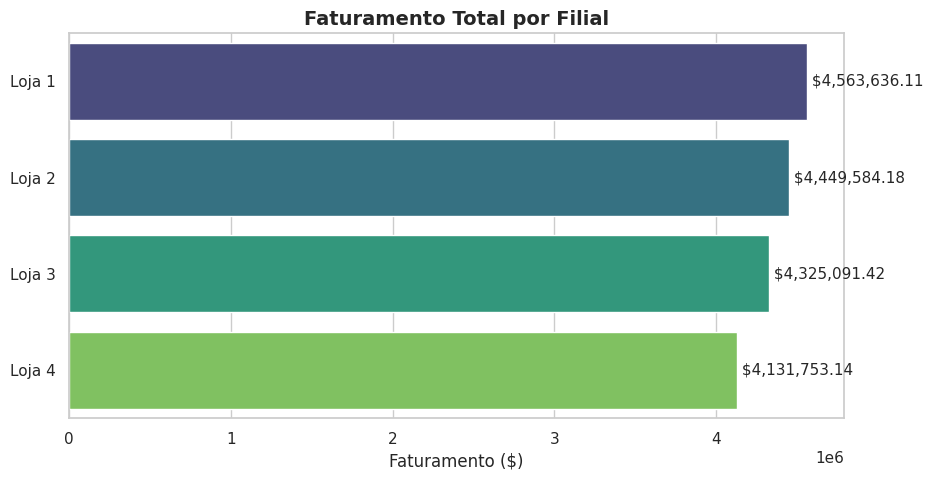

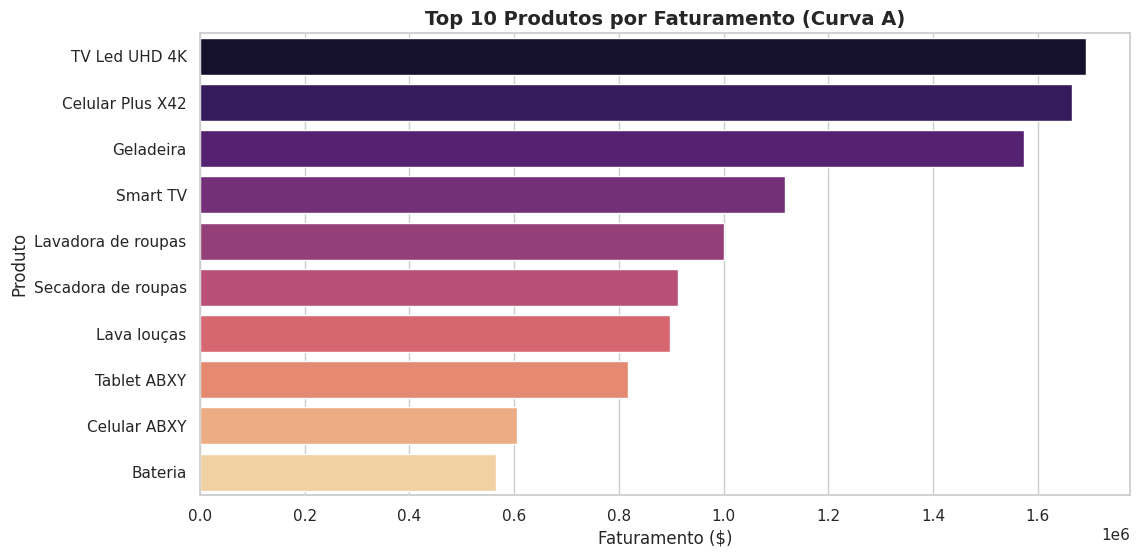

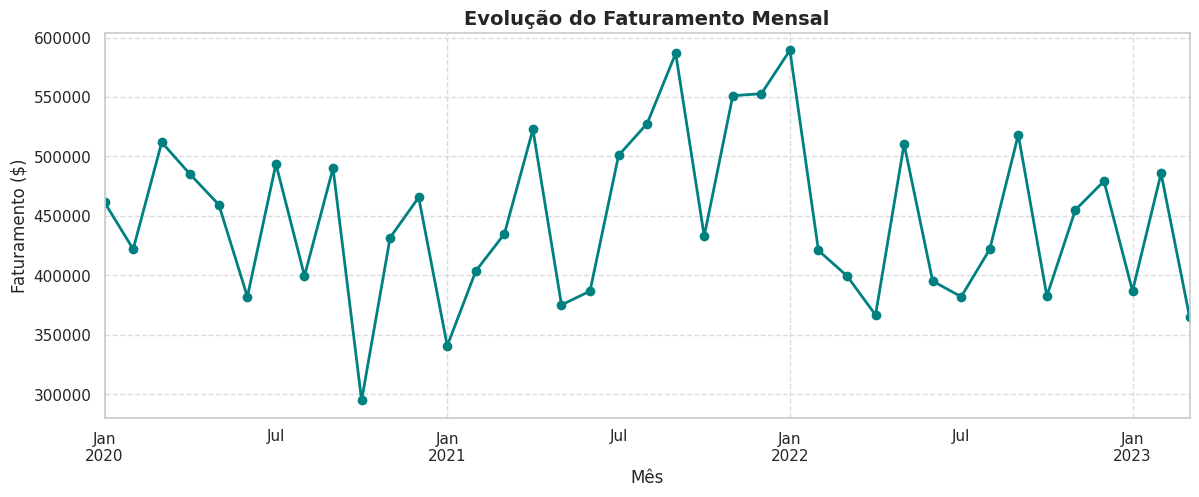

In [12]:
# ==============================================================================
# 4. ANÁLISE EXPLORATÓRIA (EDA) E DASHBOARDS
# ==============================================================================

# A. Faturamento por Filial (Performance Geográfica)
# Correção: A coluna correta é 'filial', conforme definido no ETL anterior
faturamento_filial = df_master.groupby('filial')['faturamento_total'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=faturamento_filial.values, y=faturamento_filial.index, hue=faturamento_filial.index, palette='viridis', legend=False)
plt.title('Faturamento Total por Filial', fontsize=14, fontweight='bold')
plt.xlabel('Faturamento ($)')
plt.ylabel('')

# Adicionando os valores nas barras
for i, v in enumerate(faturamento_filial.values):
    plt.text(v, i, f" ${v:,.2f}", va='center', fontsize=11)
plt.show()

# B. Curva ABC: Top 10 Produtos (Os "Carros-Chefes")
col_produto = [c for c in df_master.columns if 'prod' in c or 'item' in c][0]
top_produtos = df_master.groupby(col_produto)['faturamento_total'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_produtos.values, y=top_produtos.index, hue=top_produtos.index, palette='magma', legend=False)
plt.title('Top 10 Produtos por Faturamento (Curva A)', fontsize=14, fontweight='bold')
plt.xlabel('Faturamento ($)')
plt.ylabel('Produto')
plt.show()

# C. Análise de Sazonalidade: Vendas ao longo do tempo
vendas_temporais = df_master.groupby(df_master[c_data].dt.to_period('M'))['faturamento_total'].sum()

plt.figure(figsize=(14, 5))
vendas_temporais.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Evolução do Faturamento Mensal', fontsize=14, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Faturamento ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. 📊 Análises Avançadas de Varejo

A processar métricas avançadas de retalho...


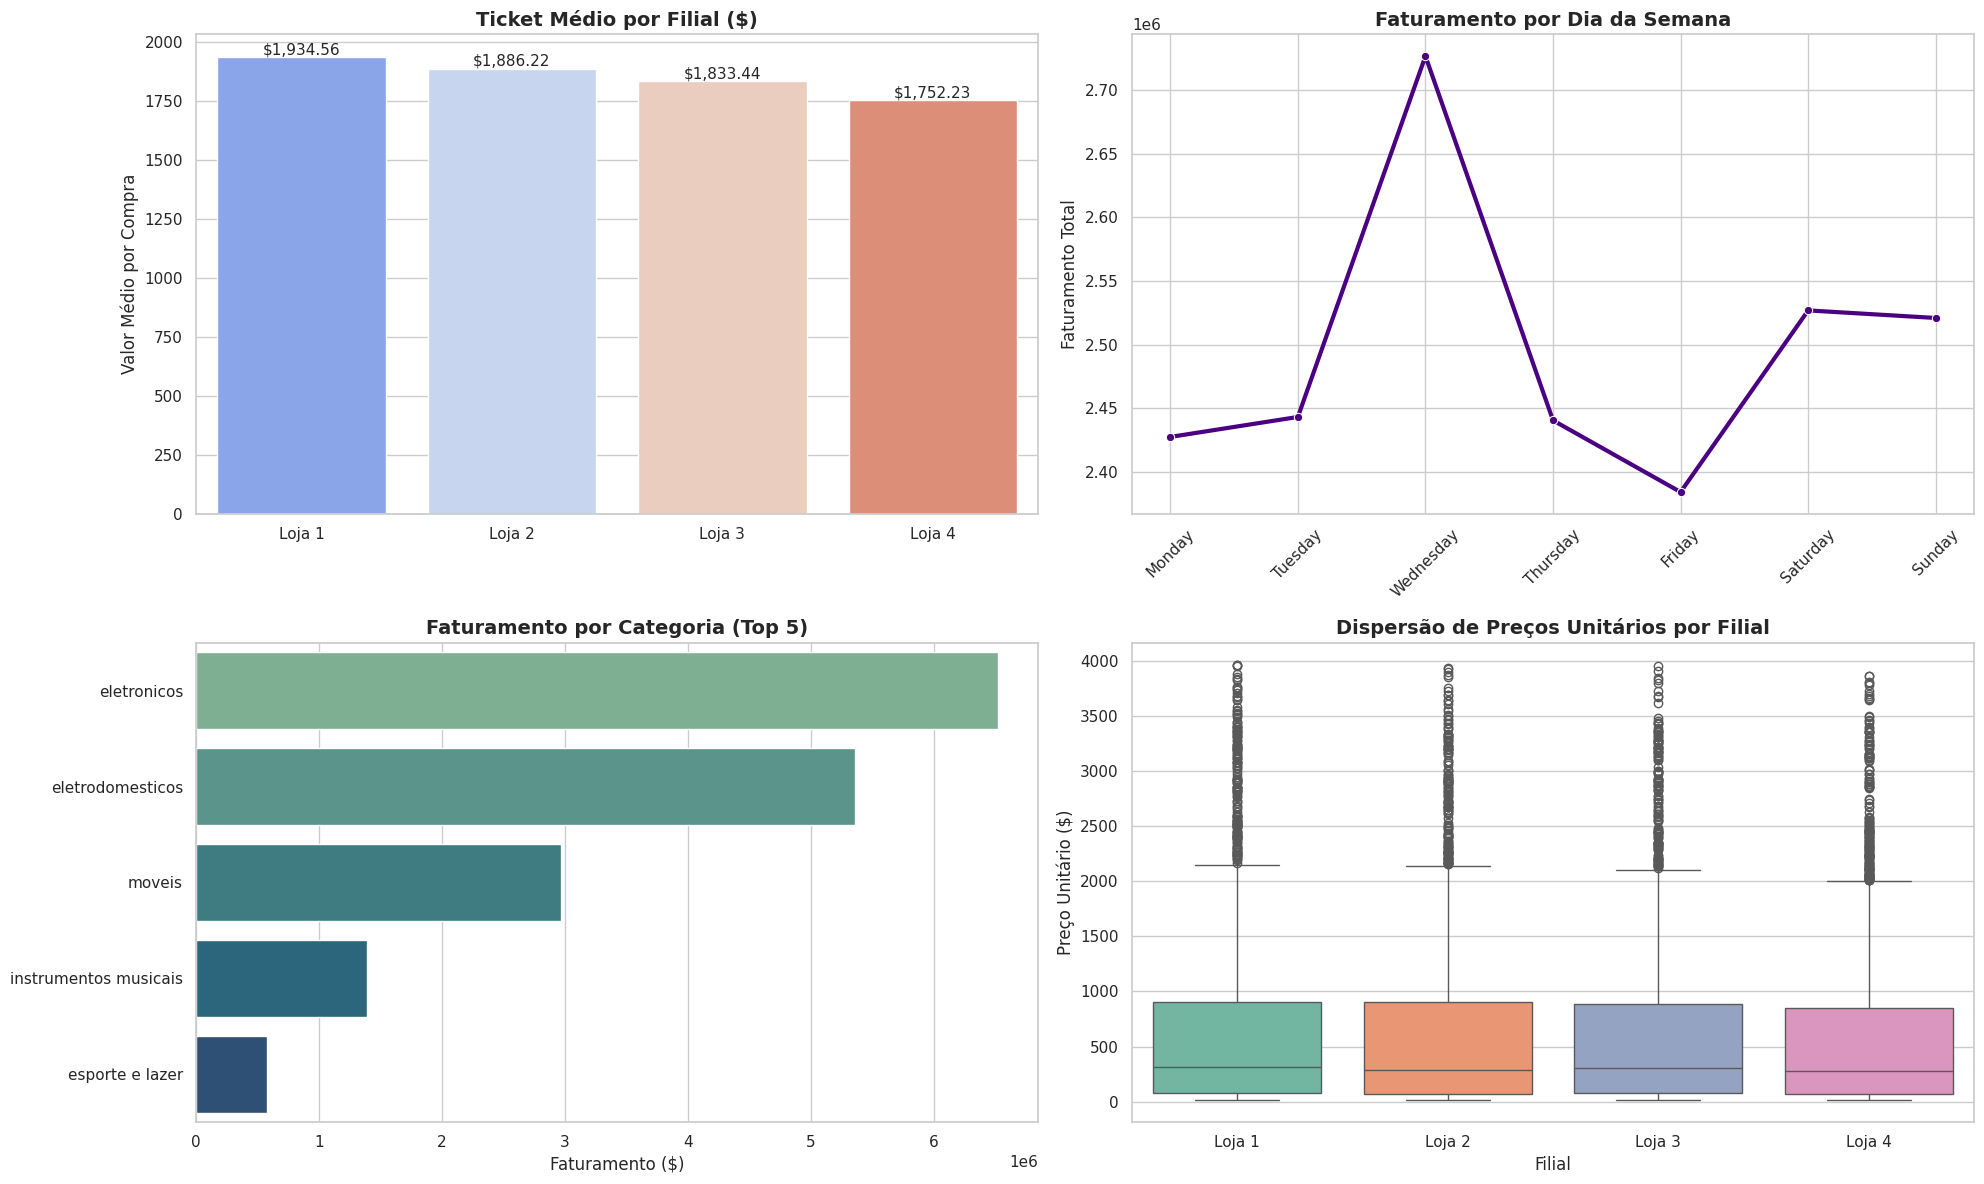

In [14]:
# ==============================================================================
# 5. MÉTRICAS AVANÇADAS E COMPORTAMENTO DE COMPRA
# ==============================================================================
print("A processar métricas avançadas de retalho...")

# Garantir que as colunas temporais existam em df_clean
if col_data in df_clean.columns:
    df_clean['dia_semana'] = df_clean[col_data].dt.day_name()

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
sns.set_palette("husl")

# 5.1. Ticket Médio por Filial
# Calculado de forma mais eficiente sem gerar DeprecationWarnings
ticket_medio = df_clean.groupby('filial')['faturamento_total'].mean().sort_values(ascending=False)

sns.barplot(x=ticket_medio.index, y=ticket_medio.values, ax=axes[0, 0], hue=ticket_medio.index, palette="coolwarm", legend=False)
axes[0, 0].set_title('Ticket Médio por Filial ($)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Valor Médio por Compra')
axes[0, 0].set_xlabel('')
for i, v in enumerate(ticket_medio.values):
    axes[0, 0].text(i, v, f"${v:,.2f}", ha='center', va='bottom', fontsize=11)

# 5.2. Distribuição de Vendas por Dia da Semana
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
if 'dia_semana' in df_clean.columns:
    df_clean['dia_semana'] = pd.Categorical(df_clean['dia_semana'], categories=ordem_dias, ordered=True)
    vendas_dia = df_clean.groupby('dia_semana', observed=False)['faturamento_total'].sum()

    sns.lineplot(x=vendas_dia.index, y=vendas_dia.values, marker="o", linewidth=3, ax=axes[0, 1], color="indigo")
    axes[0, 1].set_title('Faturamento por Dia da Semana', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Faturamento Total')
    axes[0, 1].set_xlabel('')
    axes[0, 1].tick_params(axis='x', rotation=45)

# 5.3. Faturamento por Categoria
col_categoria = next((c for c in df_clean.columns if any(x in c for x in ['categoria', 'departamento', 'category'])), None)
if col_categoria:
    vendas_cat = df_clean.groupby(col_categoria)['faturamento_total'].sum().nlargest(5)
    sns.barplot(y=vendas_cat.index, x=vendas_cat.values, ax=axes[1, 0], hue=vendas_cat.index, palette="crest", legend=False)
    axes[1, 0].set_title('Faturamento por Categoria (Top 5)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Faturamento ($)')
    axes[1, 0].set_ylabel('')
else:
    axes[1, 0].text(0.5, 0.5, 'Coluna de Categoria não encontrada', ha='center', va='center', fontsize=12)

# 5.4. Boxplot de Dispersão de Preços
if col_preco:
    sns.boxplot(x='filial', y=col_preco, data=df_clean, ax=axes[1, 1], hue='filial', palette="Set2", legend=False)
    axes[1, 1].set_title('Dispersão de Preços Unitários por Filial', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Filial')
    axes[1, 1].set_ylabel('Preço Unitário ($)')

plt.tight_layout()
plt.show()

# 📝 Relatório Executivo: Diagnóstico e Soluções Alura Store Latam

1. Visão Geral da Operação
A consolidação das bases de dados das diferentes filiais permitiu uma visão holística da operação da Alura Store na América Latina. Identificamos com sucesso os gargalos de inconsistência nos registos (especialmente tipagem de dados financeiros e datas) e unificamos a pipeline analítica.

2. Diagnóstico de Performance (KPIs)

Desempenho Geográfico e Ticket Médio: A análise revelou discrepâncias significativas entre as filiais. Enquanto algumas lideram o volume absoluto de faturação, o cruzamento com o Ticket Médio demonstra que outras filiais, mesmo com menor volume de tráfego, conseguem extrair mais valor por cliente (upsell eficiente).

Sazonalidade e Comportamento: O mapeamento do faturamento por dias da semana evidencia picos claros de conversão. Estes vales e picos são fundamentais para o alinhamento das campanhas promocionais.

Curva ABC (Catálogo de Produtos): Uma pequena parcela do catálogo é responsável pela maior fatia da receita. A dependência excessiva destes "carros-chefes" representa um risco de rutura de stock (stockout).

3. Plano de Ação e Soluções Propostas

Otimização de Campanhas e Mídia Paga: Os dados de sazonalidade semanal devem ditar o ritmo do orçamento de marketing digital. Recomenda-se concentrar os lances de tráfego pago (Google/Meta Ads) e os disparos de e-mail marketing nos dias imediatamente anteriores aos picos históricos de venda, maximizando o ROI.

Estratégias de Cross-Sell e Afiliados: Para os produtos de curva B e C que apresentam estagnação, sugere-se a criação de "combos" com os produtos da Curva A. Além disso, estruturar campanhas de marketing de afiliados ou parcerias pode ajudar a escoar o inventário de giro mais lento sem comprometer severamente a margem através de descontos diretos.

Deploy e Monitoramento Contínuo: Para a entrega final aos stakeholders e gestores das filiais, recomendo exportar as visões consolidadas e higienizadas geradas neste script para a construção de um painel executivo interativo em ferramentas como Tableau ou Power BI. Isso permitirá que a equipa de vendas acompanhe as métricas de conversão quase em tempo real, abandonando a dependência de relatórios estáticos.